##  Model Components ( Hours & Employees)




In [ ]:
import collections

# 1. Define the updated list of operating hours, H, from 9 AM to 6 PM (18:00)
H = list(range(9, 19)) # 9 AM to 6 PM (18:00) inclusive
Hd = H

# 2. Define the updated list of weekend morning hours, Hweekend
Hweekend = list(range(9, 13)) # 9 AM to 12 PM (12:00) inclusive

# 3. Expand the list of employees, E, to include new employees
E = ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Henry']

# Existing days (unchanged)
D = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
Dweekend = ['Sat', 'Sun']

# 4. Update the we dictionary with wage rates for all employees
we = {
    'Alice': 20, 'Bob': 22, 'Charlie': 18, 'David': 25, 'Eve': 19,
    'Frank': 21, 'Grace': 23, 'Henry': 20
}

# 5. Update the dh dictionary to represent the staffing demand for each day and hour
# Initialize dh with default values (e.g., 0) for new hours, then update specific demands
dh = collections.defaultdict(int)

# Default demand for new operating hours
for d in D:
    for h in H:
        if 9 <= h <= 11: # Morning peak
            dh[(d, h)] = 2
        elif 12 <= h <= 14: # Lunch peak
            dh[(d, h)] = 3
        elif 15 <= h <= 17: # Afternoon steady
            dh[(d, h)] = 2
        else: # Early/Late hours
            dh[(d, h)] = 1

# Adjust weekend demand
for d in Dweekend:
    for h in H:
        if 9 <= h <= 12: # Weekend morning/lunch peak
            dh[(d, h)] = 4
        elif 13 <= h <= 16: # Weekend afternoon
            dh[(d, h)] = 3
        else: # Weekend late
            dh[(d, h)] = 2

# Specific adjustments to ensure coverage
dh[('Sat', 10)] = 4 # Increased demand
dh[('Sun', 11)] = 4 # Increased demand

# Convert defaultdict back to dict for Pyomo Param
dh = dict(dh)

# 6. Create or update the Aeh dictionary for employee availability
Aeh = collections.defaultdict(int)

# Existing employees general availability for new hours (example, adjust as needed)
for h_val in H:
    # Alice: Mon-Fri mornings, Sat afternoon
    if h_val in range(9, 15): # 9 AM to 2 PM
        for day in ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']:
            Aeh[('Alice', day, h_val)] = 1
    if h_val in range(13, 19): # 1 PM to 6 PM
        Aeh[('Alice', 'Sat', h_val)] = 1

    # Bob: Tue-Sat afternoons
    if h_val in range(12, 19): # 12 PM to 6 PM
        for day in ['Tue', 'Wed', 'Thu', 'Fri', 'Sat']:
            Aeh[('Bob', day, h_val)] = 1

    # Charlie: Mon, Wed, Fri all day, Sun all day
    for day in ['Mon', 'Wed', 'Fri', 'Sun']:
        Aeh[('Charlie', day, h_val)] = 1

    # David: Flexible, mostly weekend and weekday evenings
    if h_val in range(12, 19): # 12 PM to 6 PM
        for day in ['Thu', 'Fri', 'Sat', 'Sun']:
            Aeh[('David', day, h_val)] = 1
    if h_val in range(9, 13): # 9 AM to 12 PM
        Aeh[('David', 'Sat', h_val)] = 1

    # Eve: Tue, Thu, Sat mornings
    if h_val in range(9, 15): # 9 AM to 2 PM
        for day in ['Tue', 'Thu', 'Sat']:
            Aeh[('Eve', day, h_val)] = 1
    # Eve also available on Mon afternoons
    if h_val in range(12, 19):
        Aeh[('Eve', 'Mon', h_val)] = 1

    # New employees
    # Frank: Mon-Fri all day, but only 6 hours max daily
    if h_val in range(9, 19): # 9 AM to 6 PM
        for day in ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']:
            Aeh[('Frank', day, h_val)] = 1

    # Grace: Weekend all day, Mon/Wed evenings
    if h_val in range(9, 19):
        for day in ['Sat', 'Sun']:
            Aeh[('Grace', day, h_val)] = 1
    if h_val in range(14, 19): # 2 PM to 6 PM
        for day in ['Mon', 'Wed']:
            Aeh[('Grace', day, h_val)] = 1

    # Henry: Everyday 9 AM to 2 PM
    if h_val in range(9, 15): # 9 AM to 2 PM
        for day in D:
            Aeh[('Henry', day, h_val)] = 1

Aeh = dict(Aeh)

# 7. Update the Me dictionary (Max Daily Hours)
Me = {
    'Alice': 8, 'Bob': 8, 'Charlie': 8, 'David': 8, 'Eve': 8,
    'Frank': 6, 'Grace': 8, 'Henry': 5
}

# 8. Update the We dictionary (Max Weekly Hours)
We = {
    'Alice': 40, 'Bob': 40, 'Charlie': 40, 'David': 35, 'Eve': 35,
    'Frank': 30, 'Grace': 35, 'Henry': 25
}

print("Sets and parameters (H, Hd, Hweekend, E, we, dh, Aeh, Me, We) updated successfully with new hours and employees.")

Sets and parameters (H, Hd, Hweekend, E, we, dh, Aeh, Me, We) updated successfully with new hours and employees.


## Initialize Pyomo Model and Variables

### Subtask:
Initialize a concrete Pyomo model and define the binary decision variables (model.x) representing whether an employee works a specific hour on a specific day, and the non-negative decision variables for unmet demand (model.y_unmet_demand).


In [ ]:
import pyomo.environ as pyo

# Initialize the concrete model (re-initializing for new subtask)
model = pyo.ConcreteModel()

# Define sets (re-defining for clarity in the new subtask, though they were updated in the previous step)
model.E = pyo.Set(initialize=E)
model.H = pyo.Set(initialize=H)
model.D = pyo.Set(initialize=D)

# Define decision variables
model.x = pyo.Var(model.E, model.D, model.H, domain=pyo.Binary, doc='Binary variable: 1 if employee e works on day d at hour h, 0 otherwise')
model.y_unmet_demand = pyo.Var(model.D, model.H, domain=pyo.NonNegativeReals, doc='Unmet demand for staffing on day d at hour h')

print("Pyomo model re-initialized and decision variables (x, y_unmet_demand) defined successfully with updated sets.")

Pyomo model re-initialized and decision variables (x, y_unmet_demand) defined successfully with updated sets.


## Formulate Objective Function

### Subtask:
Implement the objective function to minimize the total cost, which includes both the total labor cost and a penalty for any unmet demand.


In [ ]:
import pyomo.environ as pyo

# Initialize the concrete model (re-initializing for new subtask)
model = pyo.ConcreteModel()

# Define sets (re-defining for clarity in the new subtask, though they were updated in the previous step)
model.E = pyo.Set(initialize=E)
model.H = pyo.Set(initialize=H)
model.D = pyo.Set(initialize=D)

# Define parameters - THIS IS THE MISSING PART
model.we = pyo.Param(model.E, initialize=we)
model.dh = pyo.Param(model.D, model.H, initialize=dh)
model.Aeh = pyo.Param(model.E, model.D, model.H, initialize=Aeh)
model.Me = pyo.Param(model.E, initialize=Me)
model.We = pyo.Param(model.E, initialize=We)

# Define decision variables
model.x = pyo.Var(model.E, model.D, model.H, domain=pyo.Binary, doc='Binary variable: 1 if employee e works on day d at hour h, 0 otherwise')
model.y_unmet_demand = pyo.Var(model.D, model.H, domain=pyo.NonNegativeReals, doc='Unmet demand for staffing on day d at hour h')

print("Pyomo model re-initialized, sets, parameters and decision variables (x, y_unmet_demand) defined successfully with updated sets.")

Pyomo model re-initialized, sets, parameters and decision variables (x, y_unmet_demand) defined successfully with updated sets.


In [ ]:
import pyomo.environ as pyo

# 1. Define a global variable for penalty_cost
penalty_cost = 100  # Example: $100 penalty for each hour of unmet demand

# 2. Create the objective function using pyo.Objective
# 3. The expression for the objective function should sum the product of each employee's wage (model.we[e])
#    and their working hours (model.x[e, d, h]) across all employees, days, and hours.
#    Then, add the sum of the product of the penalty_cost and the model.y_unmet_demand[d, h] across all days and hours.
model.total_cost = pyo.Objective(expr=
    sum(model.x[e, d, h] * model.we[e] for e in model.E for d in model.D for h in model.H) +
    sum(model.y_unmet_demand[d, h] * penalty_cost for d in model.D for h in model.H),
    sense=pyo.minimize,
    doc='Minimize total cost (labor cost + unmet demand penalty)'
)

print("Objective function (total_cost) defined successfully.")

Objective function (total_cost) defined successfully.


## Add Constraints

### Subtask:
Add all specified constraints to the Pyomo model: minimum staffing levels (modified to include unmet demand variable), employee availability, maximum daily working hours per employee, and maximum weekly working hours per employee.

In [ ]:
import pyomo.environ as pyo

# Initialize the concrete model (re-initializing for new subtask)
model = pyo.ConcreteModel()

# Define sets (re-defining for clarity in the new subtask, though they were updated in the previous step)
model.E = pyo.Set(initialize=E)
model.H = pyo.Set(initialize=H)
model.D = pyo.Set(initialize=D)

# Define parameters - THIS IS THE MISSING PART
model.we = pyo.Param(model.E, initialize=we)
model.dh = pyo.Param(model.D, model.H, initialize=dh)
model.Aeh = pyo.Param(model.E, model.D, model.H, initialize=Aeh, default=0) # Added default=0 here
model.Me = pyo.Param(model.E, initialize=Me)
model.We = pyo.Param(model.E, initialize=We)

# Define decision variables
model.x = pyo.Var(model.E, model.D, model.H, domain=pyo.Binary, doc='Binary variable: 1 if employee e works on day d at hour h, 0 otherwise')
model.y_unmet_demand = pyo.Var(model.D, model.H, domain=pyo.NonNegativeReals, doc='Unmet demand for staffing on day d at hour h')

print("Pyomo model re-initialized, sets, parameters and decision variables (x, y_unmet_demand) defined successfully with updated sets.")

Pyomo model re-initialized, sets, parameters and decision variables (x, y_unmet_demand) defined successfully with updated sets.


In [ ]:
import pyomo.environ as pyo

# 1. Minimum Staffing Constraint
def MinStaffing_rule(model, d, h):
    return sum(model.x[e, d, h] for e in model.E) + model.y_unmet_demand[d, h] >= model.dh[d, h]
model.MinStaffingConstraint = pyo.Constraint(model.D, model.H, rule=MinStaffing_rule,
                                            doc='Minimum staffing level for each day and hour, allowing for unmet demand')

# 2. Employee Availability Constraint
def EmployeeAvailability_rule(model, e, d, h):
    return model.x[e, d, h] <= model.Aeh[e, d, h]
model.EmployeeAvailabilityConstraint = pyo.Constraint(model.E, model.D, model.H, rule=EmployeeAvailability_rule,
                                                     doc='Employee can only work if available')

# 3. Max Daily Hours Constraint
def MaxDailyHours_rule(model, e, d):
    return sum(model.x[e, d, h] for h in model.H) <= model.Me[e]
model.MaxDailyHoursConstraint = pyo.Constraint(model.E, model.D, rule=MaxDailyHours_rule,
                                              doc='Maximum daily working hours per employee')

# 4. Max Weekly Hours Constraint
def MaxWeeklyHours_rule(model, e):
    return sum(model.x[e, d, h] for d in model.D for h in model.H) <= model.We[e]
model.MaxWeeklyHoursConstraint = pyo.Constraint(model.E, rule=MaxWeeklyHours_rule,
                                               doc='Maximum weekly working hours per employee')

print("All specified constraints added to the Pyomo model successfully.")

All specified constraints added to the Pyomo model successfully.


## Solve the Optimization Problem



## Display Optimal Schedule and Costs

### Subtask:
Extract and display the optimal employee schedule, the total minimized cost (including penalty), and the actual labor cost. Also, print a summary of weekly hours per employee and any total unmet demand hours.


In [ ]:
import pyomo.environ as pyo
import pandas as pd

# Adjust the penalty_cost to a higher value to prioritize scheduling employees
penalty_cost = 500  # Increased from 100

# Redefine the objective function with the new penalty_cost
model.total_cost = pyo.Objective(expr=
    sum(model.x[e, d, h] * model.we[e] for e in model.E for d in model.D for h in model.H) +
    sum(model.y_unmet_demand[d, h] * penalty_cost for d in model.D for h in model.H),
    sense=pyo.minimize,
    doc='Minimize total cost (labor cost + unmet demand penalty)'
)

print(f"Penalty cost updated to: ${penalty_cost}")
print("Objective function (total_cost) redefined successfully with new penalty cost.")

# Re-solve the model
# Ensure solver is defined; if not, re-instantiate it (assuming cbc is installed and path is correct)
solver = pyo.SolverFactory('cbc', executable='/usr/bin/cbc')
solver.options['seconds'] = 300

results = solver.solve(model, tee=True) # tee=True prints solver output to console

if (results.solver.status == pyo.SolverStatus.ok) and (results.solver.termination_condition == pyo.TerminationCondition.optimal):
    print("\nSolver found an optimal solution after re-run.")
    model.solutions.load_from(results)
elif results.solver.termination_condition == pyo.TerminationCondition.infeasible:
    print("\nSolver reported the problem is infeasible after re-run.")
else:
    print(f"\nSolver did not find an optimal solution after re-run. Termination condition: {results.solver.termination_condition}")
    print(f"Solver status: {results.solver.status}")

# Extract and display the optimal schedule and costs again
optimal_total_cost = pyo.value(model.total_cost)
actual_labor_cost = sum(pyo.value(model.x[e, d, h]) * model.we[e]
                        for e in model.E for d in model.D for h in model.H)
total_unmet_demand_hours_calculated = sum(pyo.value(model.y_unmet_demand[d, h])
                                        for d in model.D for h in model.H)

print(f"\nOptimal Total Minimized Cost (after re-run): ${optimal_total_cost:,.2f}")
print(f"Actual Total Labor Cost (after re-run): ${actual_labor_cost:,.2f}")
print(f"Total Unmet Demand Hours (after re-run): {total_unmet_demand_hours_calculated:.2f} hours")

schedule_data = []
for d in model.D:
    for h in model.H:
        scheduled_employees = [
            e for e in model.E if pyo.value(model.x[e, d, h]) == 1
        ]
        scheduled_count = len(scheduled_employees)
        unmet_demand = pyo.value(model.y_unmet_demand[d, h])
        required_staff = model.dh[d, h]

        schedule_data.append({
            'Day': d,
            'Hour': h,
            'Required': required_staff,
            'Scheduled': scheduled_count,
            'Unmet Demand': unmet_demand,
            'Employees': ', '.join(scheduled_employees) if scheduled_employees else 'None'
        })
optimal_schedule_df = pd.DataFrame(schedule_data)

weekly_hours_data = []
for e in model.E:
    hours_worked = sum(pyo.value(model.x[e, d, h]) for d in model.D for h in model.H)
    max_hours_allowed = model.We[e]
    weekly_hours_data.append({
        'Employee': e,
        'Hours Worked': hours_worked,
        'Max Hours Allowed': max_hours_allowed
    })
weekly_employee_hours_df = pd.DataFrame(weekly_hours_data)

print("\nOptimal Employee Schedule (after re-run):")
print(optimal_schedule_df)

print("\nWeekly Hours per Employee (after re-run):")
print(weekly_employee_hours_df)


Penalty cost updated to: $500
Objective function (total_cost) redefined successfully with new penalty cost.
Welcome to the CBC MILP Solver 
Version: 2.10.7 
Build Date: Feb 14 2022 

command line - /usr/bin/cbc -seconds 300 -printingOptions all -import /tmp/tmpdwbtzwad.pyomo.lp -stat=1 -solve -solu /tmp/tmpdwbtzwad.pyomo.soln (default strategy 1)
seconds was changed from 1e+100 to 300
Option for printingOptions changed from normal to all
Presolve 91 (-603) rows, 359 (-271) columns and 613 (-1697) elements
Statistics for presolved model
Original problem has 560 integers (560 of which binary)
Presolved problem has 289 integers (289 of which binary)
==== 0 zero objective 8 different
40 variables have objective of 18
25 variables have objective of 19
78 variables have objective of 20
50 variables have objective of 21
35 variables have objective of 22
30 variables have objective of 23
31 variables have objective of 25
70 variables have objective of 500
==== absolute objective values 8 diffe

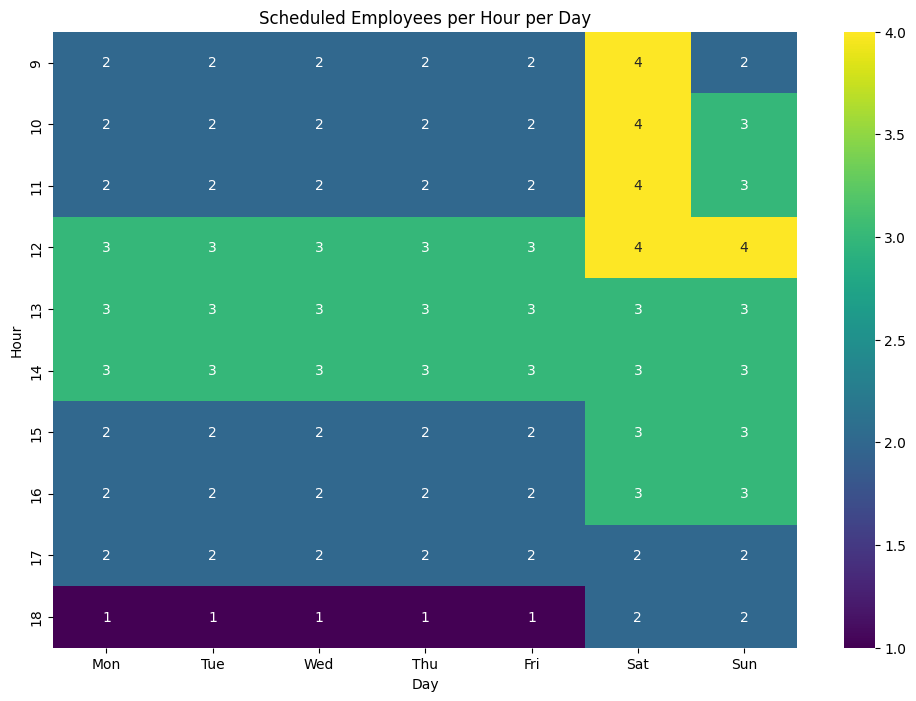

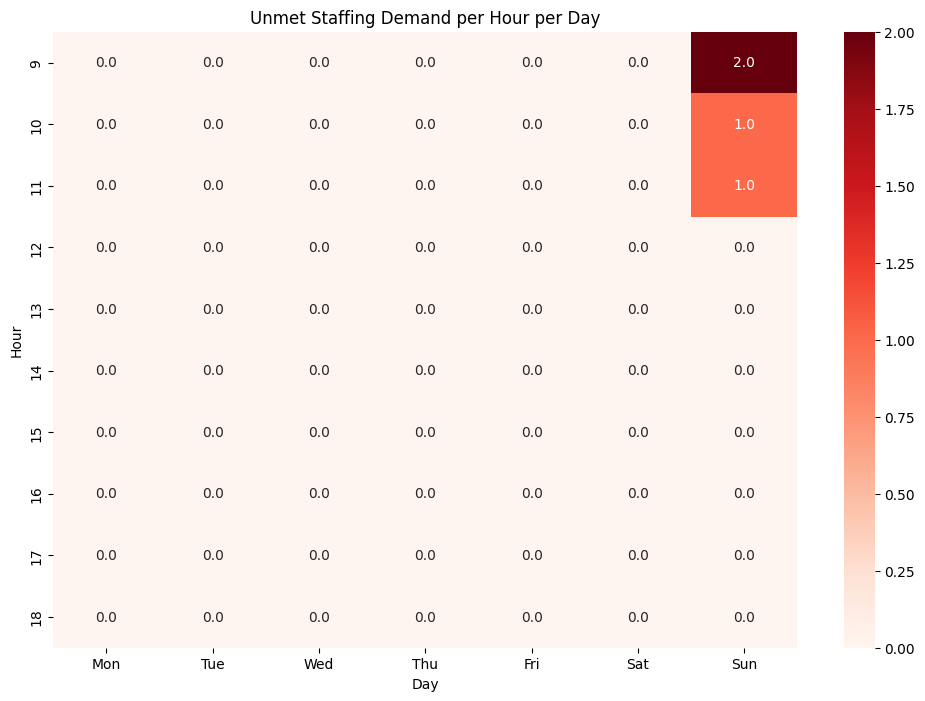

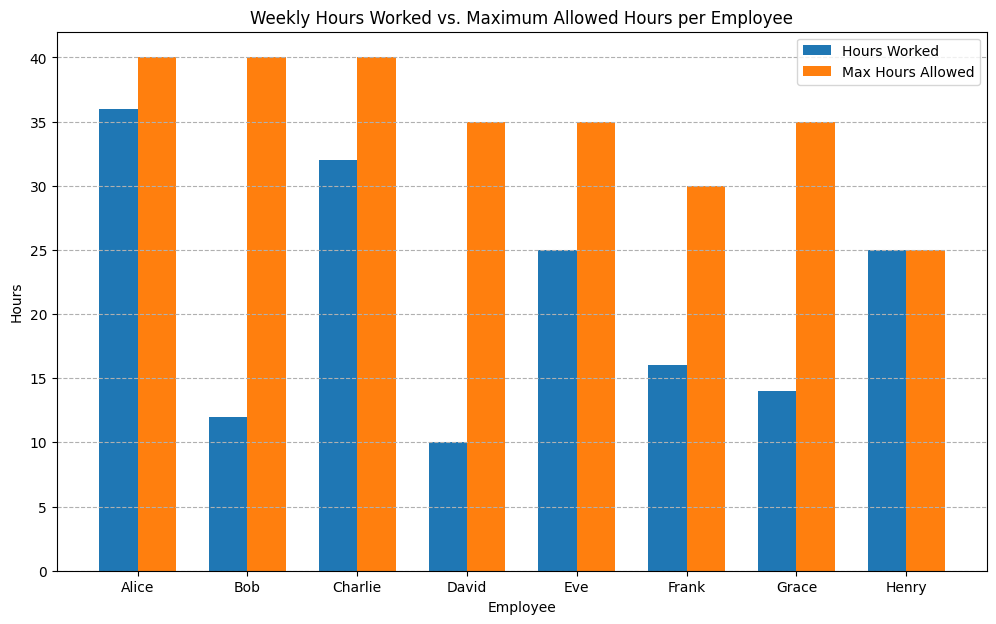

Visualizations generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Create a pivot table for scheduled employees
staffing_heatmap_data = optimal_schedule_df.pivot_table(
    index='Hour',
    columns='Day',
    values='Scheduled'
).reindex(columns=D) # Ensure correct day order

# 3. Generate a heatmap for scheduled employees
plt.figure(figsize=(12, 8))
sns.heatmap(staffing_heatmap_data, annot=True, fmt='.0f', cmap='viridis')
plt.title('Scheduled Employees per Hour per Day')
plt.xlabel('Day')
plt.ylabel('Hour')
plt.show()

# 4. Create a pivot table for unmet demand
unmet_demand_per_day_hour = optimal_schedule_df.pivot_table(
    index='Hour',
    columns='Day',
    values='Unmet Demand'
).reindex(columns=D) # Ensure correct day order

# 5. Generate a heatmap for unmet staffing demand
plt.figure(figsize=(12, 8))
sns.heatmap(unmet_demand_per_day_hour, annot=True, fmt='.1f', cmap='Reds')
plt.title('Unmet Staffing Demand per Hour per Day')
plt.xlabel('Day')
plt.ylabel('Hour')
plt.show()

# 6. Generate a bar chart for weekly hours worked per employee
plt.figure(figsize=(12, 7))
bar_width = 0.35
index = range(len(weekly_employee_hours_df))

plt.bar(index, weekly_employee_hours_df['Hours Worked'], bar_width, label='Hours Worked')
plt.bar([i + bar_width for i in index], weekly_employee_hours_df['Max Hours Allowed'], bar_width, label='Max Hours Allowed')

plt.xlabel('Employee')
plt.ylabel('Hours')
plt.title('Weekly Hours Worked vs. Maximum Allowed Hours per Employee')
plt.xticks([i + bar_width / 2 for i in index], weekly_employee_hours_df['Employee'])
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

print("Visualizations generated successfully.")